# wSMI Quick Look

Initial sanity check of the freshly computed connectivity matrices.

We start by importing the standard libraries and pointing to the output folder with the saved `.npz` files.

In [10]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "data/processed/wsmi/events_tmin-0p2_tmax15/k3_tau8ms_csd_nice"
if not OUTPUT_DIR.exists():
    raise FileNotFoundError(f"{OUTPUT_DIR!r} does not exist.")

plt.rcParams['figure.dpi'] = 120


Next we list the first few `.npz` files to confirm that the expected patient exports are present.

In [11]:
npz_files = sorted(OUTPUT_DIR.glob('*.npz'))
print(f'Found {len(npz_files)} files in {OUTPUT_DIR.as_posix()}')
for npz_path in npz_files[:5]:
    print(' -', npz_path.name)

if not npz_files:
    raise RuntimeError('No npz files detected—ensure the compute step finished successfully.')

Found 75 files in //regionh.top.local/dfs/Logget/AuditData/CONNECT-ME/Bjoern/eeg-bachelor/data/processed/wsmi/events_tmin-0p2_tmax15/k3_tau8ms_csd_nice
 - patient10_raw_wsmi_k3_tau8ms.npz
 - patient11_raw_wsmi_k3_tau8ms.npz
 - patient12_raw_wsmi_k3_tau8ms.npz
 - patient13_raw_wsmi_k3_tau8ms.npz
 - patient14_raw_wsmi_k3_tau8ms.npz


We now load the first file and inspect shapes, channel labels, events, and metadata to make sure everything looks reasonable.

In [12]:
sample_path = npz_files[0]
with np.load(sample_path, allow_pickle=True) as sample_npz:
    wsmi = sample_npz['wsmi']
    events = sample_npz['events']
    ch_names = sample_npz['ch_names']
    # Optional passthrough fields from compute_wsmi.py (present in new runs)
    event_labels = sample_npz['event_labels'] if 'event_labels' in sample_npz.files else None
    event_codes = sample_npz['event_codes'] if 'event_codes' in sample_npz.files else None
    event_names = sample_npz['event_names'] if 'event_names' in sample_npz.files else None
    meta_json_raw = sample_npz['meta_json'] if 'meta_json' in sample_npz.files else None

# Decode meta_json into a Python dict if available
if meta_json_raw is not None:
    meta_json = meta_json_raw.item() if getattr(meta_json_raw, 'ndim', 0) == 0 else str(meta_json_raw)
    meta = json.loads(meta_json)
else:
    meta = {}

print(f'Selected file: {sample_path.name}')
print(f'wSMI shape: {wsmi.shape} (epochs, channels, channels)')
print(f'Events shape: {events.shape}')
print('First 5 channels:', list(ch_names[:5]))
if meta:
    print('Meta keys:', sorted(list(meta.keys())))
else:
    print('Meta keys: (none)')

# Quick peek at event label mapping if present
if event_labels is not None:
    uniq_labels, counts = np.unique(event_labels, return_counts=True)
    print('Event labels:', {str(l): int(c) for l, c in zip(uniq_labels[:5], counts[:5])}, '...')
if event_codes is not None and event_names is not None:
    code_name_map = {int(c): str(n) for c, n in zip(event_codes, event_names)}
    print('Code→name (unique):', dict(list(code_name_map.items())[:5]))

Selected file: patient10_raw_wsmi_k3_tau8ms.npz
wSMI shape: (33, 19, 19) (epochs, channels, channels)
Events shape: (33,)
First 5 channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3']
Meta keys: ['csd_applied', 'k', 'sfreq', 'source_epochs', 'tau_ms']
Event labels: {'Familiar voice': 10, 'Medical staff': 10, 'Montage is now: ComAvg': 2, 'Montage is now: Db Banan': 1, 'Montage is now: Long': 1} ...
Code→name (unique): {2: 'Familiar voice', 4: 'Medical staff', 5: 'Montage is now: ComAvg', 6: 'Montage is now: Db Banan', 7: 'Montage is now: Long'}


visualise the first epoch of the first patient to eyeball the raw connectivity matrix.

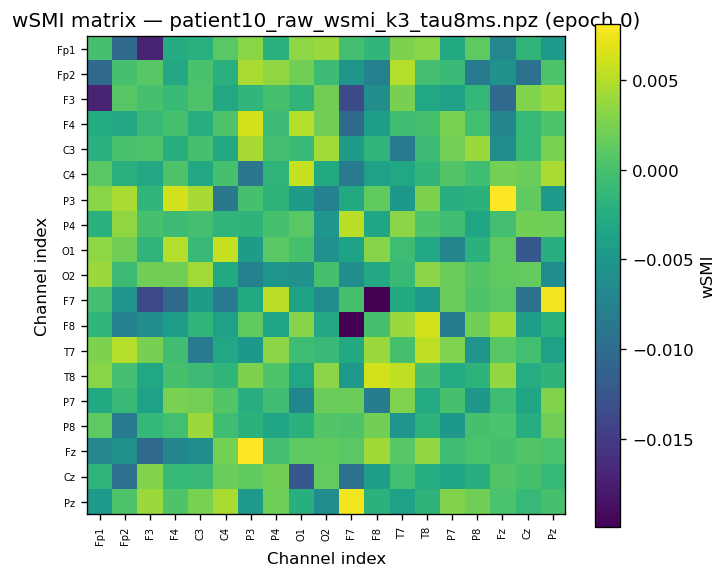

wSMI value range: min=-0.0281, max=0.0134
Mean wSMI value across all epochs and channel pairs: -0.0012


In [ ]:
epoch_idx = 0
matrix = wsmi[epoch_idx]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix, cmap='viridis')
ax.set_title(f'wSMI matrix — {sample_path.name} (epoch {epoch_idx})')
ax.set_xlabel('Channel index')
ax.set_ylabel('Channel index')
step = max(1, len(ch_names) // 20)
tick_positions = np.arange(0, len(ch_names), step)
ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)
ax.set_xticklabels(ch_names[tick_positions], rotation=90, fontsize=6)
ax.set_yticklabels(ch_names[tick_positions], fontsize=6)
fig.colorbar(im, ax=ax, label='wSMI')
plt.tight_layout()
plt.show()

# Show the range of the values
print(f'wSMI value range: min={wsmi.min():.4f}, max={wsmi.max():.4f}')

# print the mean of the wSMI matrix
mean_wsmi = np.mean(wsmi)
print(f'Mean wSMI value across all epochs and channel pairs: {mean_wsmi:.4f}')

To compare across participants, we repeat the quick plot for the second file.

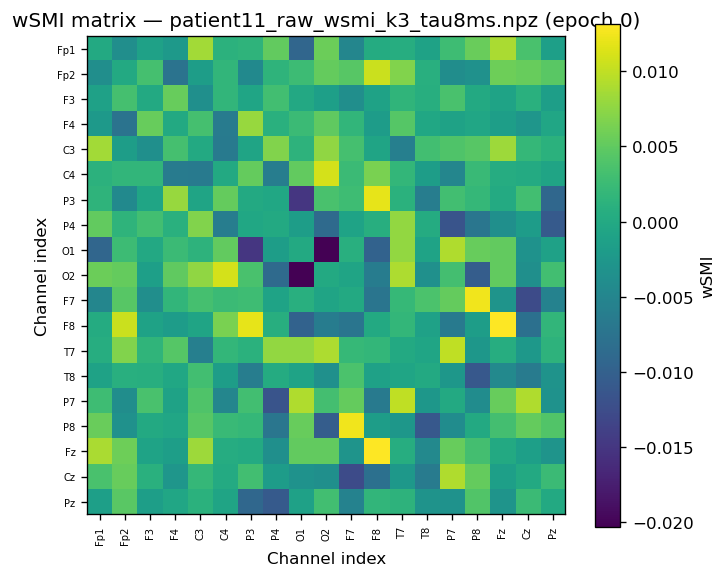

In [14]:
if len(npz_files) > 1:
    second_path = npz_files[1]
    with np.load(second_path, allow_pickle=True) as second_npz:
        wsmi_second = second_npz['wsmi']
        ch_names_second = second_npz['ch_names']
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(wsmi_second[0], cmap='viridis')
    ax.set_title(f'wSMI matrix — {second_path.name} (epoch 0)')
    ax.set_xlabel('Channel index')
    ax.set_ylabel('Channel index')
    step = max(1, len(ch_names_second) // 20)
    tick_positions = np.arange(0, len(ch_names_second), step)
    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_xticklabels(ch_names_second[tick_positions], rotation=90, fontsize=6)
    ax.set_yticklabels(ch_names_second[tick_positions], fontsize=6)
    fig.colorbar(im, ax=ax, label='wSMI')
    plt.tight_layout()
    plt.show()
else:
    print('Only one npz file available—skipping second preview.')


# Check what events are present in the wSMI matrices

In [15]:
# Overview of NPZ contents for a selected file
# Change file_idx to inspect a different file from npz_files
file_idx = 0  # 0 = first file
sel_path = npz_files[file_idx]
print(f"Inspecting: {sel_path.name}")

with np.load(sel_path, allow_pickle=True) as npz:
    keys = list(npz.files)
    print(f"Keys ({len(keys)}): {keys}")
    print("\nSummary per key:")
    for k in keys:
        v = npz[k]
        if isinstance(v, np.ndarray):
            if v.ndim == 0:
                # Scalar-like (may be an object for meta_json)
                dt = v.dtype
                if k == 'meta_json':
                    try:
                        meta_json = v.item()
                        import json as _json
                        meta = _json.loads(meta_json)
                        meta_keys = sorted(list(meta.keys())) if isinstance(meta, dict) else []
                        print(f" - {k}: meta_json (keys: {meta_keys})")
                    except Exception as e:
                        print(f" - {k}: 0-dim object (could not parse as JSON): {e}")
                else:
                    print(f" - {k}: 0-dim array, dtype={dt}")
            else:
                shape = tuple(int(s) for s in v.shape)
                dt = v.dtype
                extra = ""
                if k in ("events", "event_labels"):
                    try:
                        uniq = np.unique(v)
                        extra = f", unique={len(uniq)}"
                    except Exception:
                        pass
                print(f" - {k}: array, shape={shape}, dtype={dt}{extra}")
        else:
            print(f" - {k}: type={type(v).__name__}")

    # Optional: print event code->name mapping
    if 'event_codes' in keys and 'event_names' in keys:
        try:
            codes = npz['event_codes']
            names = npz['event_names']
            mapping = {int(c): str(n) for c, n in zip(codes, names)}
            shown = dict(list(mapping.items())[:10])
            print("\nEvent code→name (first 10):", shown)
        except Exception as e:
            print("\nCould not build event mapping:", e)


Inspecting: patient10_raw_wsmi_k3_tau8ms.npz
Keys (7): ['wsmi', 'events', 'event_labels', 'event_codes', 'event_names', 'ch_names', 'meta_json']

Summary per key:
 - wsmi: array, shape=(33, 19, 19), dtype=float32
 - events: array, shape=(33,), dtype=int64, unique=12
 - event_labels: array, shape=(33,), dtype=object, unique=12
 - event_codes: array, shape=(12,), dtype=int64
 - event_names: array, shape=(12,), dtype=object
 - ch_names: array, shape=(19,), dtype=object
 - meta_json: meta_json (keys: ['csd_applied', 'k', 'sfreq', 'source_epochs', 'tau_ms'])

Event code→name (first 10): {2: 'Familiar voice', 4: 'Medical staff', 5: 'Montage is now: ComAvg', 6: 'Montage is now: Db Banan', 7: 'Montage is now: Long', 8: 'Montage is now: Trans', 9: 'Resting', 10: 'der gives medicin', 11: 'spl tager prøve', 12: 'spl taler omkring pt ifm. medicingivning'}


## Event counts per subject and condition (stacked dataset)

The cell below loads the stacked dataset NPZ and prints:
- totals per subject
- totals per condition
- a subject × condition heatmap

Tip: adjust DATASET_PATH if needed.

Dataset: //regionh.top.local/dfs/Logget/AuditData/CONNECT-ME/Bjoern/eeg-bachelor/data/processed/wsmi/events_tmin-0p2_tmax15_familiar_medical_resting_nice_csd/events_tmin-0p2_tmax15_familiar_medical_resting_nice_csd_k3_tau8ms_stack.npz
Subjects (75): P10, P11, P12, P13, P14, P15, P16, P17, P18, P19, P20, P21, P22, P23, P24, P25, P27, P28, P29, P02, P30, P31, P32, P33, P34, P35, P36, P37, P38, P39, P03, P40, P41, P42, P43, P44, P45, P46, P47, P48, P49, P04, P50, P51, P52, P53, P54, P56, P57, P58, P59, P05, P60, P61, P62, P63, P65, P66, P67, P68, P69, P06, P71, P72, P73, P74, P75, P76, P77, P78, P79, P07, P80, P08, P09
Conditions (3): Resting, Familiar voice, Medical staff
N=1736, P=171


<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
C:\Users\bmoe0112\AppData\Local\Temp\ipykernel_17800\187698217.py:13: SyntaxWarning: invalid escape sequence '\p'
  DATASET_PATH = PROJECT_ROOT / "data\processed\wsmi\events_tmin-0p2_tmax15_familiar_medical_resting_nice_csd\events_tmin-0p2_tmax15_familiar_medical_resting_nice_csd_k3_tau8ms_stack.npz"


,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P27,P28,P29,P02,P30,P31,P32,P33,P34,P35,P36,P37,P38,P39,P03,P40,P41,P42,P43,P44,P45,P46,P47,P48,P49,P04,P50,P51,P52,P53,P54,P56,P57,P58,P59,P05,P60,P61,P62,P63,P65,P66,P67,P68,P69,P06,P71,P72,P73,P74,P75,P76,P77,P78,P79,P07,P80,P08,P09
Count,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23,24,23,23,23,23,23,23,23,23,23,31,23,23,24,23,23,23,23,23,24,23,23,23,23,22,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23,24,22,23,24,23,24,23,23,23,23,23,22,23



Counts per condition:
 - Resting: 228
 - Familiar voice: 755
 - Medical staff: 753


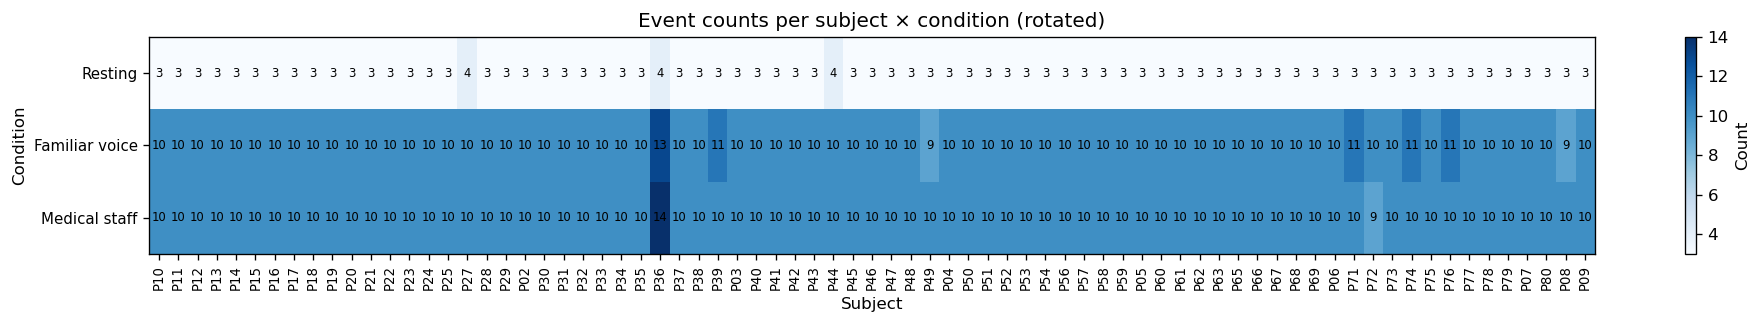

In [20]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML

# Locate project root (folder containing 'data')
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

# Path to the stacked dataset (adjust if you saved it elsewhere)
DATASET_PATH = PROJECT_ROOT / "data\processed\wsmi\events_tmin-0p2_tmax15_familiar_medical_resting_nice_csd\events_tmin-0p2_tmax15_familiar_medical_resting_nice_csd_k3_tau8ms_stack.npz"
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Stacked dataset not found at: {DATASET_PATH}")

with np.load(DATASET_PATH, allow_pickle=False) as ds:
    y_cond = ds['y_cond'].astype(np.int64)        # shape (N,)
    groups = ds['groups'].astype(np.int64)        # shape (N,)
    subjects = ds['subjects'].astype(str)         # shape (S,)
    conditions = ds['conditions'].astype(str)     # shape (C,)
    N = int(ds['N']) if 'N' in ds.files else len(y_cond)
    P = int(ds['P']) if 'P' in ds.files else -1

print(f"Dataset: {DATASET_PATH.as_posix()}")
print(f"Subjects ({len(subjects)}): {', '.join(subjects)}")
print(f"Conditions ({len(conditions)}): {', '.join(conditions)}")
print(f"N={N}" + (f", P={P}" if P > 0 else ""))

# Counts per subject and condition
subj_counts = np.bincount(groups, minlength=len(subjects))
cond_counts = np.bincount(y_cond, minlength=len(conditions))

# Subject counts wide table (like the rotated plot): one row, subjects as columns
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
df_subj_wide = pd.DataFrame([subj_counts.astype(int)], columns=subjects, index=['Count'])
display(HTML(f"<div style='overflow-x:auto; white-space:nowrap'>{df_subj_wide.to_html()}</div>"))

print("\nCounts per condition:")
for c_idx, c in enumerate(conditions):
    print(f" - {c}: {int(cond_counts[c_idx])}")

# Build S x C contingency table
table = np.zeros((len(subjects), len(conditions)), dtype=np.int64)
for g, y in zip(groups, y_cond):
    table[g, y] += 1

# Rotate the heatmap 90° so subjects are on the x-axis (wide) and conditions on the y-axis
table_T = table.T  # shape (C, S)

# Heatmap (wide figure; short height)
fig_width = max(6.0, 0.22 * len(subjects))
fig_height = max(2.8, 0.6 * len(conditions))
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
im = ax.imshow(table_T, cmap='Blues', aspect='auto')
ax.set_title('Event counts per subject × condition (rotated)')
ax.set_xlabel('Subject')
ax.set_ylabel('Condition')
ax.set_xticks(np.arange(len(subjects)))
ax.set_yticks(np.arange(len(conditions)))
ax.set_xticklabels(subjects, rotation=90, fontsize=8)
ax.set_yticklabels(conditions, fontsize=9)
cbar = fig.colorbar(im, ax=ax, label='Count')

# Always annotate each cell with its count
for i in range(len(conditions)):
    for j in range(len(subjects)):
        ax.text(j, i, int(table_T[i, j]), ha='center', va='center', color='black', fontsize=7)

plt.tight_layout()
plt.show()